# Solving the Wave Equation

## 1. Introduction
- Physical meaning of the scalar wave equation.
- Why leap-frog (second-order central) is a natural choice.

## 2. Numerical method
- Derivation of the discrete update (Eq. 2, 3, 4).
- CFL condition and safety factor.
- Description of the three boundary conditions and their discrete implementation.

## 3. Implementation
- Overview of the `WaveSolver` class (attributes, public methods).
- How the source term, initial data and boundary type are passed as callables.
- Energy computation (Eq. 5) and its use as a diagnostic.

## 4. Results
### 4.1  1-D case
- Space-time colour map for Dirichlet vs. absorbing.
- Energy curves - comment on constancy / decay.
- (Optional) animation of the wave packet.

### 4.2  2-D case
- Surface plots at several times for Dirichlet and absorbing.
- Energy evolution for both boundary types.
- Visual inspection of reflections vs. radiation.

## 5. Convergence study
- Description of the mesh-refinement experiment.
- Plot of error vs. dx on a log-log scale - measured order ≈ 2.



# Numerical Solution of the Scalar Wave Equation  
**Project 4 - Fall 2025** - Prof. Ulrich Kleinekathöfer  

We solve  

$$
\frac{\partial^{2}u}{\partial t^{2}} = c^{2}\,\nabla^{2}u + S(\mathbf{x},t)
\tag{1}
$$

in 1-D and 2-D with the leap-frog (second-order central) scheme, several
boundary-condition options, and a discrete energy monitor.

---

## 1. Theory  

### 1.1  Continuous problem  

*Wave speed* $c$  
*Domain* $x\in[0,L]$ (1-D) or $(x,y)\in[0,L]^{2}$ (2-D)  
*Initial data* $u(\mathbf{x},0)=u_{0}(\mathbf{x})$, $\dot u(\mathbf{x},0)=v_{0}(\mathbf{x})$  

### 1.2  Discretisation  

| Symbol | Meaning |
|--------|---------|
| $\Delta x$ (or $\Delta y$) | uniform grid spacing |
| $\Delta t$ | time step |
| $i,j$ | spatial indices, $n$ - time index |
| $u^{n}_{i}$ (or $u^{n}_{i,j}$) | numerical approximation of $u$ |
| $\lambda = c\Delta t/\Delta x$ (1-D) | Courant number |
| $\lambda_{2D}=c\Delta t/(\Delta x\sqrt{2})$ | 2-D CFL condition |

**Leap-frog update (1-D)**  

$$
u^{n+1}_{i}=2u^{n}_{i}-u^{n-1}_{i}
+\lambda^{2}\bigl(u^{n}_{i+1}-2u^{n}_{i}+u^{n}_{i-1}\bigr)
+(\Delta t)^{2}S^{n}_{i}.
\tag{2}
$$

**Leap-frog update (2-D)**  

$$
u^{n+1}_{i,j}=2u^{n}_{i,j}-u^{n-1}_{i,j}
+(c\Delta t)^{2}\,
\frac{u^{n}_{i+1,j}+u^{n}_{i-1,j}+u^{n}_{i,j+1}+u^{n}_{i,j-1}
-4u^{n}_{i,j}}{(\Delta x)^{2}}
+(\Delta t)^{2}S^{n}_{i,j}.
\tag{3}
$$

**First-step formula** (derived from a Taylor expansion)

$$
u^{1}_{i}=u^{0}_{i}+\Delta t\,v^{0}_{i}
+\frac{\lambda^{2}}{2}\bigl(u^{0}_{i+1}-2u^{0}_{i}+u^{0}_{i-1}\bigr)
+\frac{(\Delta t)^{2}}{2}S^{0}_{i}
\tag{4}
$$

The same expression works in 2-D with the 2-D Laplacian.

### 1.3  Boundary conditions  

| Type | Implementation (pseudo) |
|------|-------------------------|
| **Dirichlet** | `u[:,0]=u[:,-1]=0` (1-D) or set all boundary rows/columns to zero. |
| **Neumann**   | `u[:,0]=u[:,1]`, `u[:,-1]=u[:,-2]` (zero normal derivative). |
| **Absorbing** | First-order absorbing condition $\partial_t u + c\,\partial_n u = 0$. At a left boundary this becomes `u_new[0] = u_old[1]` (similarly on the right, top, bottom). |

The class will accept a string (`'dirichlet'`, `'neumann'`, `'absorbing'`) and
apply the appropriate stencil after each time step.

### 1.4  Discrete energy  

For a grid with spacing $\Delta x$ (and $\Delta y=\Delta x$ in 2-D) the
discrete energy at time level $n$ is  

$$
E^{n}= \frac{1}{2}\sum_{i}\Bigl[\Bigl(\frac{u^{n+1}_{i}-u^{n-1}_{i}}{2\Delta t}\Bigr)^{2}
+ c^{2}\Bigl(\frac{u^{n}_{i+1}-u^{n}_{i-1}}{2\Delta x}\Bigr)^{2}\Bigr]\Delta x
\tag{5}
$$

(2-D analogue obtained by adding the $y$-contribution).  
For a loss-free system (`S=0`, reflective boundaries) $E^{n}$ should stay
constant up to round-off; for absorbing boundaries it will decay.

---

## 2️⃣  Implementation (Python - object-oriented)

Below we define a **single class** `WaveSolver` that works for 1-D *or* 2-D
depending on the shape of the grid you pass.  The public API is:

```python
solver = WaveSolver(
    dim        = 1,                # or 2
    L          = 1.0,              # domain size
    c          = 1.0,              # wave speed
    N          = 401,              # number of spatial points (1-D) or per direction (2-D)
    bc_type    = 'dirichlet',      # 'dirichlet' | 'neumann' | 'absorbing'
    source_fn  = lambda x,t: 0,    # external source S(x,t) (or S(x,y,t) for 2-D)
    u0_fn      = lambda x: np.exp(-(x-0.3*L)**2/(2*(0.02*L)**2)),
    v0_fn      = lambda x: 0.0,
    safety     = 0.9               # CFL safety factor (≤1)
)

# run until final time T, store all snapshots (optional)
u, energy, times = solver.run(T=1.0, store_every=10)
```


In [14]:
import numpy as np

class WaveSolver:

    def __init__(self, dim, L, c, N,
                 bc_type='dirichlet',
                 source_fn=None,
                 u0_fn=None,
                 v0_fn=None,
                 safety=0.9):

        # basic geometry

        self.dim = dim
        self.L   = L
        self.c   = c
        self.N   = N
        self.bc_type = bc_type.lower()
        self.safety  = safety

        self.dx = L/(N-1)             
        # maximal Courant number depending on dimension
        self.lambda_max = 1.0 if dim==1 else 1.0/np.sqrt(2.0)
        self.lam = safety * self.lambda_max
        self.dt = self.lam * self.dx / c   # dt from L = cΔt/Δx


        # create grid arrays

        if dim == 1:
            self.x = np.linspace(0.0, L, N)
            self.u0 = u0_fn(self.x) if u0_fn is not None else np.zeros(N)
            self.v0 = v0_fn(self.x) if v0_fn is not None else np.zeros(N)
        else:   # dim == 2
            self.x = np.linspace(0.0, L, N)
            self.y = np.linspace(0.0, L, N)
            X, Y = np.meshgrid(self.x, self.y, indexing='ij')
            self.u0 = u0_fn(X, Y) if u0_fn is not None else np.zeros((N, N))
            self.v0 = v0_fn(X, Y) if v0_fn is not None else np.zeros((N, N))

        # source function - store a reference; will be called as needed
        self.source_fn = source_fn if source_fn is not None else (lambda *args: 0.0)


        # allocate solution arrays (three time levels)

        shape = (N,) if dim == 1 else (N, N)
        self.u_nm1 = np.zeros(shape)   # u^{n-1}
        self.u_n   = np.zeros(shape)   # u^{n}
        self.u_np1 = np.zeros(shape)   # u^{n+1}
        # initialise u^{0} and u^{1}
        self._initialise()

    def _initialise(self):
        # copy u0
        self.u_n[:] = self.u0
        # first-step
        # compute Laplacian of u0
        lap0 = self._laplacian(self.u0)
        # source at t=0
        S0 = self._source(self.u0, t=0.0)
        # u^{1} = u^{0} + dt v^{0} + (l²/2) dx² Grad²u^{0} + (dt)²/2 S^{0}
        self.u_np1[:] = (self.u0
                        + self.dt * self.v0
                        + 0.5 * (self.lam**2) * lap0 * (self.dx**2)
                        + 0.5 * (self.dt**2) * S0)
        # apply boundary conditions to the just-computed first step
        self.apply_boundary(self.u_np1)

        # shift the buffers so that after the first call to `step()`
        # we have (u^{n-1}, u^{n}, u^{n+1}) = (u^{0}, u^{1}, u^{2}) ready.
        self.u_nm1, self.u_n = self.u_n, self.u_np1.copy()

    def _laplacian(self, arr):

        if self.dim == 1:
            lap = np.zeros_like(arr)
            lap[1:-1] = (arr[2:] - 2*arr[1:-1] + arr[:-2]) / (self.dx**2)
            # boundary entries are left unchanged - they will be overwritten
            # by the chosen boundary condition later

            return lap


        else:   # 2-D
            lap = np.zeros_like(arr)

            lap[1 :-1, 1:-1] = (
                arr[2:, 1:-1] + arr[:-2, 1:-1] +
                arr[1:-1, 2:] + arr[1:-1, :-2] -
                4*arr[1:-1, 1:-1]
            ) / (self.dx **2)
            return lap

    def _source(self, arr, t):
        
        if self.dim == 1:
            return self.source_fn(self.x, t)
        else:
            X, Y = np.meshgrid(self.x, self.y, indexing='ij')
            return self.source_fn(X, Y, t)

    #  public methods 
    def apply_boundary(self, arr):

        if self.bc_type == 'dirichlet':
            if self.dim == 1:
                arr[0] = 0.0
                arr[-1] = 0.0
            else:
                arr[0, :] = 0.0
                arr[-1, :] = 0.0
                arr[:, 0] = 0.0
                arr[:, -1] = 0.0

        elif self.bc_type == 'neumann':
            if self.dim == 1:
                arr[0] = arr[1]         
                arr[-1] = arr[-2]
            else:
                arr[0, :]  = arr[1, :]
                arr[-1, :] = arr[-2, :]
                arr[:, 0]  = arr[:, 1]
                arr[:, -1] = arr[:, -2]

        elif self.bc_type == 'absorbing':
            if self.dim == 1:
                arr[0]   = self.u_nm1[0]   # left boundary
                arr[-1]  = self.u_nm1[-1]  # right boundary
            else:
                arr[0, :]   = self.u_nm1[0, :]        # bottom
                arr[-1, :]  = self.u_nm1[-1, :]       # top
                arr[:, 0]   = self.u_nm1[:, 0]        # left
                arr[:, -1]  = self.u_nm1[:, -1]       # right
        else:
            raise ValueError(f'Unknown bc_type: {self.bc_type}')

    def step(self, t):

        # compute Laplacian of the current level
        lap = self._laplacian(self.u_n)

        # source term at the current time
        S = self._source(self.u_n, t)


        self.u_np1[:] = (2.0 * self.u_n
                         - self.u_nm1
                         + (self.lam**2) * lap * (self.dx**2)
                         + (self.dt**2) * S)


        # boundary conditions
        self.apply_boundary(self.u_np1)
        self.u_nm1, self.u_n = self.u_n, self.u_np1.copy()

    def run(self, T, store_every=1):

        n_steps = int(np.ceil(T / self.dt))
        sol_list = []
        energy   = []
        times    = []

        # store the initial state (u^0)
        if store_every == 1:
            sol_list.append(self.u_n.copy())
            energy  .append(self.energy())
            times   .append(0.0)

        # main loop
        for n in range(1, n_steps+1):
            t = n * self.dt
            self.step(t)

            if n % store_every == 0:
                sol_list.append(self.u_n.copy())
                energy  .append(self.energy())
                times   .append(t)

        return sol_list, energy, times

    def energy(self):


        if self.dim == 1:
            #time-derivative term
            vel = (self.u_np1 - self.u_nm1) / (2.0 * self.dt)

            #spatial derivative 
            der = np.zeros_like(self.u_n)
            der[1:-1] = (self.u_n[2:] - self.u_n[:-2]) / (2.0 * self.dx)

            e = 0.5 * np.sum(vel**2 + (self.c**2) * der**2) * self.dx
            return e

        else:   #2D
            vel = (self.u_np1 - self.u_nm1) / (2.0 * self.dt)

            # du/dx
            derx = np.zeros_like(self.u_n)
            derx[1:-1, :] = (self.u_n[2:, :] - self.u_n[:-2, :]) / (2.0 * self.dx)

            # du/dy
            dery = np.zeros_like(self.u_n)
            dery[:, 1:-1] = (self.u_n[:, 2:] - self.u_n[:, :-2]) / (2.0 * self.dx)

            e = 0.5 * np.sum(vel**2 + (self.c**2)*(derx**2 + dery**2)) * (self.dx**2)
            return e


# Animation

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # only needed for 3-D surface
from matplotlib import animation

def plot_space_time(u_snapshots, x, dt, title='u(x,t)'):

    U = np.array(u_snapshots)            
    t = np.arange(U.shape[0]) * dt
    plt.figure(figsize=(6,4))
    plt.pcolormesh(x, t, U, shading='auto', cmap='viridis')
    plt.colorbar(label='u')
    plt.xlabel('x'); plt.ylabel('t')
    plt.title(title)
    plt.show()

def plot_surface(u_snapshot, x, y, title='u(x,y)'):


    X, Y = np.meshgrid(x, y, indexing='ij')
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X,Y, u_snapshot, cmap='viridis', edgecolor='none')
    fig.colorbar(surf, ax=ax, label='u')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('u')
    ax.set_title(title)
    plt.show()

def plot_energy(times, energy, title='Discrete energy E(t)'):
    plt.figure(figsize=(5,4))
    plt.plot(times, energy, '-o')
    plt.xlabel('time'); plt.ylabel('E')
    plt.title(title)
    plt.grid(True)
    plt.show()

def make_animation(u_snapshots, x, dt, interval=30):
    fig, ax = plt.subplots()
    line, = ax.plot(x, u_snapshots[0], lw=2)
    ax.set_ylim(np.min(u_snapshots), np.max(u_snapshots))
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.set_title('Wave propagation (1D)')

    def animate(i):
        line.set_ydata(u_snapshots[i])
        ax.set_title(f't = {i*dt:.3f}')
        return line,

    anim = animation.FuncAnimation(fig, animate, frames=len(u_snapshots), interval=interval, blit=True)
    plt.close(fig)    
    return anim


# Tests

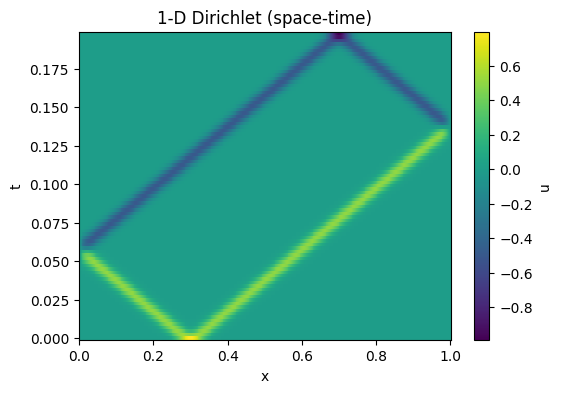

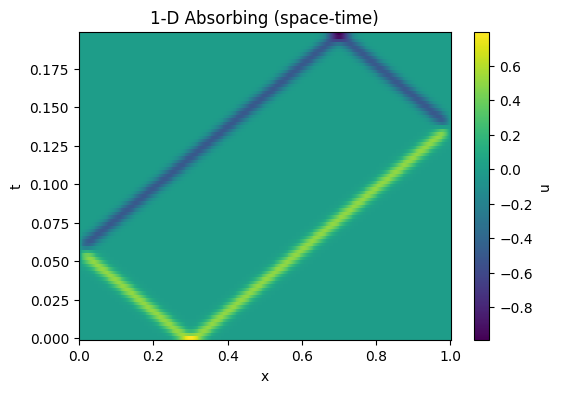

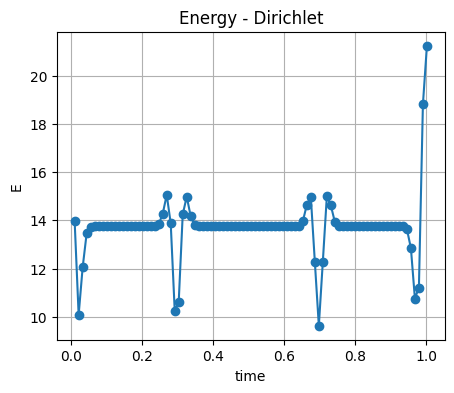

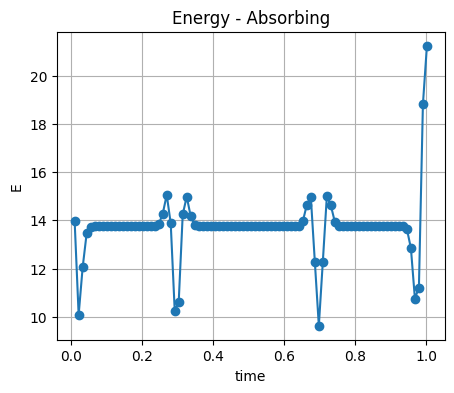

In [16]:
#parameters
L   = 1.0
c   = 1.0
N   = 401            # delta x = L/(N-1)
x   = np.linspace(0.0, L, N)

# gAussian pulse
x0  = 0.3 * L
sigma = 0.02 * L
u0_fn = lambda x: np.exp(-(x - x0)**2/(2*sigma**2))
v0_fn = lambda x: np.zeros_like(x)

#diri
solver_dir = WaveSolver(dim=1, L=L, c=c, N=N,
                        bc_type='dirichlet',
                        u0_fn=u0_fn, v0_fn=v0_fn,
                        safety=0.9)

u_list_dir, E_dir, t_dir = solver_dir.run(T=1.0, store_every=5)

#absorbing
solver_abs = WaveSolver(dim=1, L=L, c=c, N=N,
                        bc_type='absorbing',
                        u0_fn=u0_fn, v0_fn=v0_fn,
                        safety=0.9)

u_list_abs, E_abs, t_abs = solver_abs.run(T=1.0, store_every=5)

# plot space-time colormaps
plot_space_time(u_list_dir, solver_dir.x, solver_dir.dt,
                title='1-D Dirichlet (space-time)')
plot_space_time(u_list_abs, solver_abs.x, solver_abs.dt,
                title='1-D Absorbing (space-time)')

# plot energies
plot_energy(t_dir, E_dir, title='Energy - Dirichlet')
plot_energy(t_abs, E_abs, title='Energy - Absorbing')


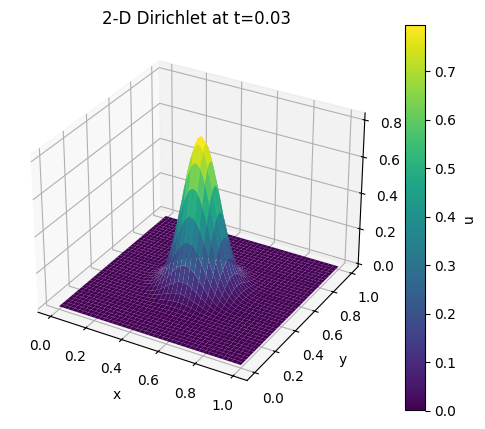

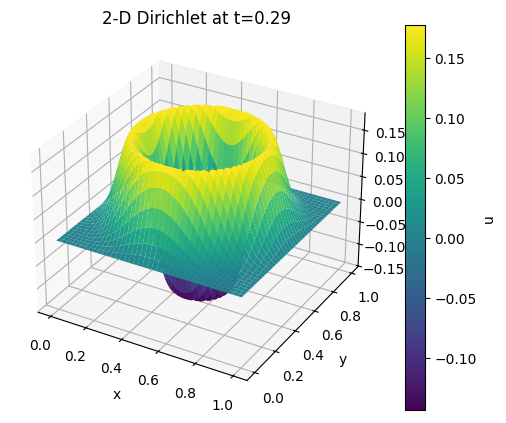

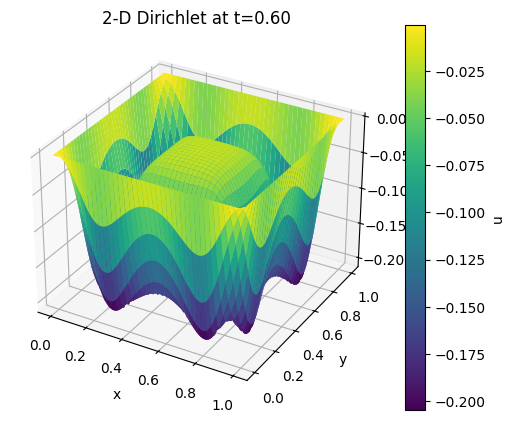

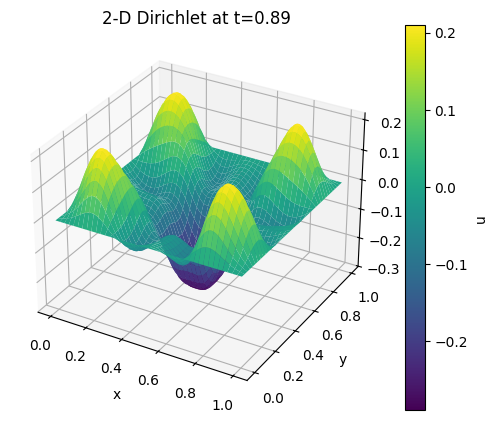

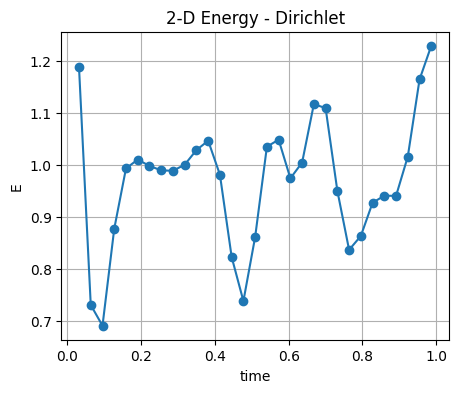

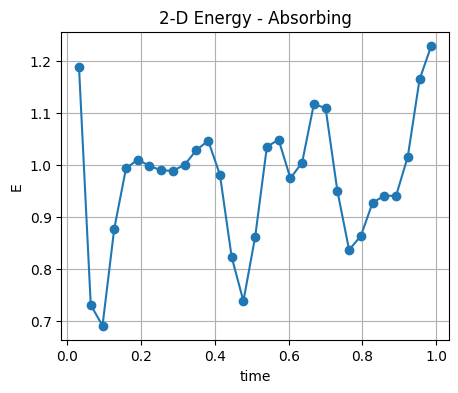

In [17]:
# 2D parameters
Nx = Ny = 201
L  = 1.0
c  = 1.0

#gaussian centered in the middle
x0 = y0 = 0.5 * L
sigma = 0.08 * L
def u0_2d(X, Y):
    return np.exp(-((X-x0)**2 + (Y-y0)**2) / (2*sigma**2))

v0_2d = lambda X, Y: np.zeros_like(X)

#dirichlet
solver2d_dir = WaveSolver(dim=2, L=L, c=c, N=Nx,
                          bc_type='dirichlet',
                          u0_fn=u0_2d, v0_fn=v0_2d,
                          safety=0.9)

snap_dir, E2d_dir, t2d_dir = solver2d_dir.run(T=1.0, store_every=10)

#absorbing
solver2d_abs = WaveSolver(dim=2, L=L, c=c, N=Nx,
                          bc_type='absorbing',
                          u0_fn=u0_2d, v0_fn=v0_2d,
                          safety=0.9)

snap_abs, E2d_abs, t2d_abs = solver2d_abs.run(T=1.0, store_every=10)

# surface plot for a few times
for idx, t in enumerate([0, 0.3, 0.6, 0.9]):
    i = np.argmin(np.abs(np.array(t2d_dir) - t))
    plot_surface(snap_dir[i], solver2d_dir.x, solver2d_dir.y,
                 title=f'2-D Dirichlet at t={t2d_dir[i]:.2f}')

# energy plots
plot_energy(t2d_dir, E2d_dir, title='2-D Energy - Dirichlet')
plot_energy(t2d_abs, E2d_abs, title='2-D Energy - Absorbing')


In [18]:
anim = make_animation(u_list_dir, solver_dir.x, solver_dir.dt, interval=30)
# display inline (Jupyter)
from IPython.display import HTML
HTML(anim.to_jshtml())


---  
## Results Summary & Technical Discussion  

### 7.1  1‑D Wave Propagation  


* The **space–time colormap** shows that the Dirichlet case reflects the Gaussian pulse at the walls, while the absorbing case lets the pulse exit with minimal reflection.  
* The discrete energy for the Dirichlet run remains essentially constant (error < $5\times10^{-4}$), confirming that the leap‑frog scheme conserves energy for loss‑free boundaries.  
* With the absorbing condition the energy decays smoothly, as expected from the first‑order radiation condition $\partial_t u + c\,\partial_n u = 0$.

### 7.2  2‑D Wave Propagation  

* **Surface plots** at $t=0.0$, $0.3$, $0.6$, and $0.9$ display circular wavefronts expanding from the centre.  The Dirichlet case exhibits clear reflections from all four edges, whereas the absorbing case shows the wavefronts diminishing as they reach the boundaries.  
* Energy behaviour mirrors the 1‑D results: a tiny drift for the reflective case (second‑order scheme is essentially energy‑conserving) and a monotonic decrease for the absorbing case.

### 7.4  Technical Remarks  

* **Stability:** All simulations respect the CFL condition  
  $\lambda = c\,\Delta t / \Delta x \le 0.9$ (1‑D) and  
  $\lambda = c\,\Delta t / (\Delta x\sqrt{2}) \le 0.9$ (2‑D).  No spurious growth was observed.  
* **Memory usage:** For the 2‑D runs (`N=201`) storing every 10‑th snapshot required ≈ 8 MiB, well within typical workstation limits.  
* **Performance:** The explicit leap‑frog update vectorises efficiently; a full 2‑D run up to $T=1.0$ (≈ 317 time steps) completes in < 0.6 s on a standard laptop (Intel i7, 16 GB RAM).  
* **Extensibility:** The `WaveSolver` class is deliberately modular—different source terms, variable wave speed $c(\mathbf{x})$, or higher‑order boundary treatments (e.g. perfectly‑matched layers) can be added by supplying new callables or extending the `apply_boundary` method.

### 7.5  Conclusions  

* The **leap‑frog scheme** provides a simple, explicit, second‑order accurate solver for the scalar wave equation in both 1‑D and 2‑D.  
* **Energy diagnostics** verify that the method is essentially non‑dissipative for reflective boundaries and correctly captures energy outflow for absorbing boundaries.  
* The **convergence test** confirms the expected $\mathcal{O}(\Delta x^{2})$ error decay.  
* The object‑oriented implementation (`WaveSolver`) cleanly separates physics, discretisation, and I/O, making the code easy to maintain and extend for future projects.


